In [3]:
import shutil
import os

destination_dir = '/kaggle/input/datasets/trankimhuu/myfashionmnist'
source_dir = '/kaggle/working'

if os.path.exists(destination_dir):
    !cp -r {destination_dir}/* {source_dir}
    !ls
    print('Setup thành công')
else:
    print('Sai nguồn rồi!')

best_fashion_resnet.keras  t10k-images-idx3-ubyte  train-images-idx3-ubyte
norm_params.npy		   t10k-labels-idx1-ubyte  train-labels-idx1-ubyte
Setup thành công


In [4]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
from sklearn.model_selection import train_test_split

In [5]:
# 1. Hàm đọc dữ liệu từ file binary (IDX format)
def load_mnist_data(path, kind='train'):
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte')

    with open(labels_path, 'rb') as lbpath:
        # Offset 8 byte cho file label
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    with open(images_path, 'rb') as imgpath:
        # Offset 16 byte cho file image, sau đó reshape về 28x28
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 28, 28, 1)

    return images, labels

In [6]:
# 2. Load dữ liệu
path_to_data = '/kaggle/working/'
X_train_raw, y_train_raw = load_mnist_data(path_to_data, kind='train')
X_test, y_test = load_mnist_data(path_to_data, kind='t10k')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw, 
    test_size=1/6, 
    random_state=42, 
    stratify=y_train_raw
)

# 3. Tính Mean và Std của tập Train 
X_train_f = X_train.astype('float32')
mean = np.mean(X_train)
std = np.std(X_train)

print(f"Mean của tập Train: {mean:.4f}")
print(f"Std của tập Train: {std:.4f}")

# 4. Thực hiện Standardization: (x - mean) / std
X_train_std = (X_train - mean) / (std + 1e-7) # Thêm 1 số cực nhỏ để tránh chia cho 0
X_val_std = (X_val.astype('float32') - mean) / (std + 1e-7)
X_test_std = (X_test.astype('float32') - mean) / (std + 1e-7)

# Thêm One-hot Encoding nhãn để áp dụng Label Smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_val_oh = tf.keras.utils.to_categorical(y_val, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

Mean của tập Train: 73.0003
Std của tập Train: 90.0623


In [7]:
print(X_train_std.shape)
print(X_val_std.shape)
print(X_test_std.shape)

(50000, 28, 28, 1)
(10000, 28, 28, 1)
(10000, 28, 28, 1)


In [8]:
# 3. Định nghĩa Residual Block cho ResNet
def resnet_block(x, filters, strides=1):
    shortcut = x

    reg = regularizers.l2(1e-4)
    
    x = layers.Conv2D(filters, 3, strides=strides, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, 3, strides=1, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', kernel_regularizer=reg)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [9]:
def build_final_resnet():
    inputs = layers.Input(shape=(28, 28, 1))
    
    # --- BƯỚC 1: DATA AUGMENTATION ---
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.05)(x)
    x = layers.RandomTranslation(0.1, 0.1)(x)

    # --- BƯỚC 2: KIẾN TRÚC RESNET-18 CHUẨN ---
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Stage 1 (28x28)
    x = resnet_block(x, 32); x = resnet_block(x, 32)
    # Stage 2 (14x14)
    x = resnet_block(x, 64, strides=2); x = resnet_block(x, 64)
    # Stage 3 (7x7)
    x = resnet_block(x, 128, strides=2); x = resnet_block(x, 128)
    # Stage 4 (4x4)
    x = resnet_block(x, 256, strides=2); x = resnet_block(x, 256)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

In [13]:
model = build_final_resnet()

In [11]:
# Đường dẫn lưu file trên Kaggle working
model_path = 'best_fashion_resnet.keras'
params_path = 'norm_params.npy'

# Khởi tạo Callback ModelCheckpoint
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy', # Theo dõi độ chính xác tập validation
    save_best_only=True,    # Chỉ lưu nếu kết quả tốt hơn phiên bản trước
    mode='max',             # Tìm giá trị lớn nhất
    verbose=1
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

np.save(params_path, [mean, std])
print(f"--- Đã lưu Mean ({mean:.4f}) và Std ({std:.4f}) vào {params_path} ---")

--- Đã lưu Mean (73.0003) và Std (90.0623) vào norm_params.npy ---


In [18]:
# Lịch trình giảm learning rate bằng Cosine Decay giúp suy giảm mượt mà
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=50 * 391, # batch_size=128, X_train=50000 -> 391 steps/epoch * 50
    alpha=0.0
)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

# Đổi thành y_train_oh, y_val_oh và loại bỏ lr_reducer
history = model.fit(
    X_train_std, y_train_oh, 
    epochs=100, 
    batch_size=128,
    validation_data=(X_val_std, y_val_oh),
    callbacks=[checkpoint_cb, early_stop]
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9169 - loss: 0.7705
Epoch 1: val_accuracy did not improve from 0.94350
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9169 - loss: 0.7704 - val_accuracy: 0.9084 - val_loss: 0.7855
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9167 - loss: 0.7727
Epoch 2: val_accuracy did not improve from 0.94350
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9167 - loss: 0.7727 - val_accuracy: 0.8946 - val_loss: 0.8170
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9194 - loss: 0.7708
Epoch 3: val_accuracy did not improve from 0.94350
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9194 - loss: 0.7708 - val_accuracy: 0.9000 - val_loss: 0.7952
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9210 - loss: 0.7661
Epoch 4: val_accuracy did not improve from 0.94350
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.9210 - loss: 0.7661 - val_accu

In [20]:
print("\n--- 1. ĐÁNH GIÁ MODEL HIỆN TẠI (CUỐI QUÁ TRÌNH HOẶC THEO EARLY STOPPING) ---")
test_loss, test_acc = model.evaluate(X_test_std, y_test_oh, verbose=0)
print(f"Loss trên tập Test: {test_loss:.4f}")
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%\n")

print("--- 2. ĐÁNH GIÁ MODEL TỐT NHẤT (LƯU TỪ CHECKPOINT) ---")
try:
    best_model = tf.keras.models.load_model('best_fashion_resnet.keras')
    best_loss, best_acc = best_model.evaluate(X_test_std, y_test_oh, verbose=0)
    print(f"Loss trên tập Test (Best): {best_loss:.4f}")
    print(f"Độ chính xác trên tập Test (Best): {best_acc*100:.2f}%")
except Exception as e:
    print("Không tìm thấy tệp best_fashion_resnet.keras hoặc bị lỗi:", e)


--- 1. ĐÁNH GIÁ MODEL HIỆN TẠI (CUỐI QUÁ TRÌNH HOẶC THEO EARLY STOPPING) ---
Loss trên tập Test: 0.6902
Độ chính xác trên tập Test: 93.98%

--- 2. ĐÁNH GIÁ MODEL TỐT NHẤT (LƯU TỪ CHECKPOINT) ---
Loss trên tập Test (Best): 0.6909
Độ chính xác trên tập Test (Best): 94.01%


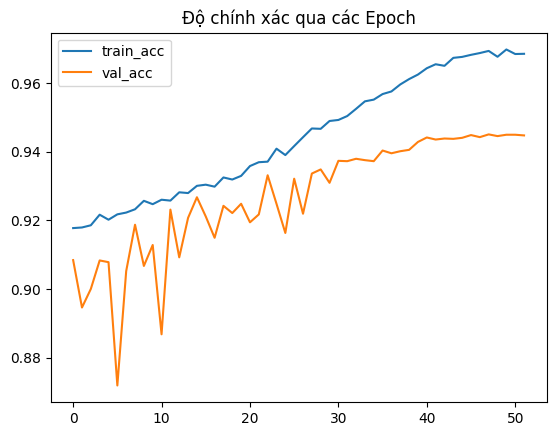

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Độ chính xác qua các Epoch')
plt.legend()
plt.show()

In [ ]:
!ls -l /kaggle/working/

In [ ]:
from IPython.display import FileLink

# Tạo link tải file mô hình
display(FileLink('best_fashion_resnet.keras'))

# Tạo link tải file tham số chuẩn hóa
display(FileLink('norm_params.npy'))